# Event-related Fields

Event-related fields (ERFs) and event-related potentials (ERPs) are neural responses that are time-locked to specific sensory, cognitive, or motor events. These responses reflect phase-locked neuronal activity elicited by discrete stimuli and are typically measured using magnetoencephalography (MEG) and electroencephalography (EEG), respectively. Both ERFs and ERPs are widely used in cognitive and clinical neuroscience to investigate the temporal dynamics of brain processing, enabling researchers to assess how the brain responds to particular tasks or sensory inputs [1,2].

The objective of this section is to compute ERFs time-locked to the onset of the attention cue and to perform basic visualisations of their temporal evolution and spatial distribution. Because the cue is itself a visual stimulus, the average reveals a visual evoked response. We will examine the time course of the ERFs and generate topographic maps illustrating the distribution of the fields across the sensor array. These analyses provide insight into the timing and localisation of the brain processes associated with the perception of visual input.

## Preparation
Import the relevant modules

In [19]:
import os.path as op
import os
import mne
from mne_bids import BIDSPath, read_raw_bids 
from mne.viz import plot_evoked_topo
from scipy.signal import detrend
import matplotlib.pyplot as plt
import numpy as np

### File overview

This chapter relies on the epoched data produced in the previous chapter (embedded in the BIDS structure):

`<BIDS_ROOT>/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif`

Set the local paths of the data below. Note that these will depend on your local setup.

In [20]:
subject = '01'
session = '01'
task    = 'SpAtt'
run     = '01'
meg_suffix = 'meg'
epo_suffix = 'epo'

# Root folder holding the BIDS dataset. Adjust to your local setup.
#data_path = 'C:/Users/rakshita/Documents/Cerca_raw_files'
data_path = '/Users/o.jensen@bham.ac.uk/Data/CercaOxf/fif'

bids_root  = op.join(data_path, "Cerca_Spatt_BIDS")
deriv_root = op.join(bids_root, "derivatives/analysis")

# Path to the epoched data produced in the previous chapter (input)
bids_path = BIDSPath(subject=subject, session=session,
            task=task, run=run, suffix=epo_suffix, datatype='meg',
            root=deriv_root, extension='.fif', check=False)

print(bids_path.basename, bids_path.fpath)

sub-01_ses-01_task-SpAtt_run-01_epo.fif /Users/o.jensen@bham.ac.uk/Data/CercaOxf/fif/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif


## Read the epochs

To read in the epochs identified in the previous chapter write

In [21]:
epochs = mne.read_epochs(bids_path.fpath,
                         proj = True,
                         preload=True,
                         verbose=False)

In [22]:
epochs

<EpochsFIF | 213 events (all good), -0.749 – 2 s (baseline off), ~599.0 MiB, data loaded,
 'cue_Left': 109
 'cue_Right': 104>

## Averaging the trial data

The epochs from the previous chapter are time-locked to the onset of the left and right attention cues. For each condition we:

1. average over trials,
2. low-pass filter the average at 30 Hz to attenuate high-frequency noise,
3. crop to the −0.1 to 0.4 s interval around cue onset,
4. remove a linear trend across the cropped interval with `scipy.signal.detrend` to suppress any residual slow drift, and
5. apply a baseline correction using the −0.1 to 0 s pre-cue window.

A high-pass filter is not required: slow drifts are handled by the per-epoch linear detrend applied when the epochs were created, together with the detrend above. Note that this detrend is fitted over the short −0.1 to 0.4 s window, which contains the evoked response itself, so it should be applied with care — over such a short segment the fitted line can be pulled by the response.

In [23]:
# Average over trials, low-pass at 30 Hz, crop around cue onset,
# then linearly detrend and finally baseline-correct to the pre-cue window
evoked_left  = epochs['cue_Left'].average(method='mean').filter(None, 30).crop(-0.1, 0.4)
evoked_left.data = detrend(evoked_left.data, axis=-1, type='linear')
evoked_left.apply_baseline(baseline=(-0.1, 0))

evoked_right = epochs['cue_Right'].average(method='mean').filter(None, 30).crop(-0.1, 0.4)
evoked_right.data = detrend(evoked_right.data, axis=-1, type='linear')
evoked_right.apply_baseline(baseline=(-0.1, 0))

Setting up low-pass filter at 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 331 samples (0.441 s)

Applying baseline correction (mode: mean)
Setting up low-pass filter at 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 331 samples (0.441 s)

Applying baseline correction (mode: mean)


<Evoked | 'cue_Right' (average, N=104), -0.1 – 0.4 s, baseline -0.1 – 0 s, 176 ch, ~6.1 MiB>

**Question 1** The average is low-pass filtered with a *non-causal, zero-phase* FIR filter. What does "zero-phase" mean, why is it desirable when measuring ERF peak *latencies*, and what artefact can a low-pass filter nevertheless introduce around sharp transients?

**Question 2** We apply a linear detrend and then a baseline correction to the −0.1 to 0 s window. Explain the difference between the two operations, and why the order (detrend, then baseline) matters here.

Now isolate the radial Z-axis sensors. These measure the field component perpendicular to the scalp and are therefore the OPM equivalent of the magnetometers in a conventional MEG system:

In [24]:
# Group the triaxial OPM channels by measurement axis (X, Y, Z)
OPMX = [item for item in epochs.ch_names if item.endswith("X")]
OPMY = [item for item in epochs.ch_names if item.endswith("Y")]
OPMZ = [item for item in epochs.ch_names if item.endswith("Z") and not item.startswith("BNC")]

# Restrict the ERFs to the radial (Z) channels
evoked_left  = evoked_left.pick(OPMZ)
evoked_right = evoked_right.pick(OPMZ)

A butterfly-plot allows for visualising the event-related fields across sensors:

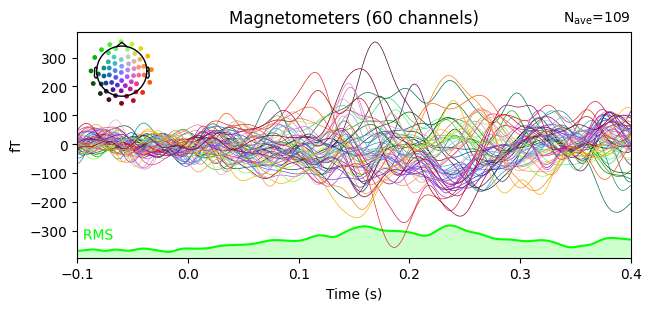

In [25]:
evoked_left.plot(gfp=True);

Here, note the large positive and negative event-related fields at respectively t = 0.170 s and t = 0.187 s

## Plotting the event-related fields arranged topographically according to senors locations

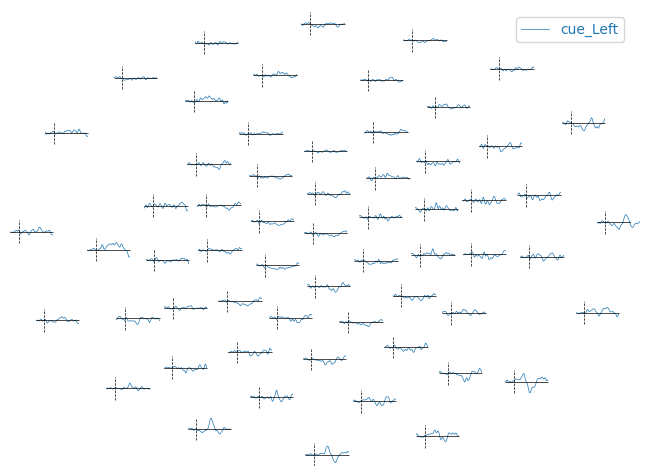

In [26]:
%matplotlib inline
evoked_left.plot_topo();

To enable interactive plotting, use %matplotlib qt instead of %matplotlib inline. This allows you to click on individual sensor plots to enlarge and inspect them in more detail.

## To plot a topographic map of the response at any specific instant of time write:

Since the Cerca/Quspin system uses triaxial sensors that measure the magnetic field along three mutually orthogonal directions, it is important to identify and separate the components corresponding to each direction and plot them individually.

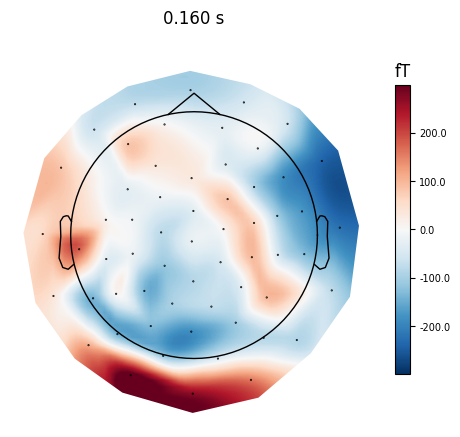

In [27]:
evoked_left.plot_topomap(times=[0.160],
    contours = 0,
    ch_type='mag',
    size=3,
    show_names=False,
    extrapolate = 'local',
    outlines = 'head'
);


**Question 3**: Explain how an equivalent current dipole (ECD) can account for the posterior event-related field by drawing the ECD on top of the topographic plot (hint: consider the 'right-hand rule')

Now plot the topographic maps across multiple time points

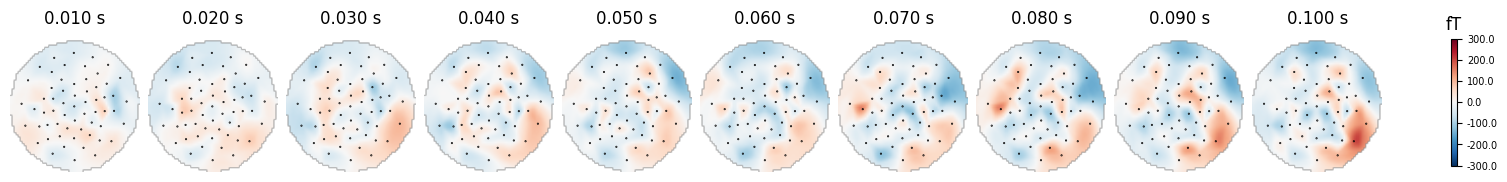

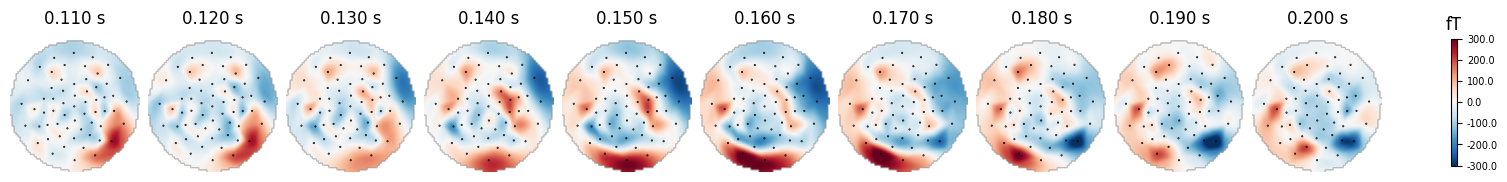

In [28]:
time_ins1 = np.linspace(0.01, 0.1, num=10) #define time points
time_ins2 = np.linspace(0.11, 0.2, num=10) #define time points
evoked_left.plot_topomap(times=time_ins1, ch_type='mag', extrapolate = 'local', contours = 0, outlines = None,vlim = (-300,300));
evoked_left.plot_topomap(times=time_ins2, ch_type='mag', extrapolate = 'local', contours = 0, outlines = None,vlim = (-300,300));

**Question 4** Follow the topographic maps from 0.01 to 0.2 s. Describe how the field pattern evolves, identify when it is most clearly dipolar, and relate the polarity rotation to the underlying neural generator.

**Question 5**: Generate the ERFs with respect to the onset of the gratings (hint, use the event cue `stimOnset`)

## Preregistration and publication

A preregistration should describe how the event-related fields are computed in enough detail to reproduce them exactly. The filtering, baseline, detrending, and analysis window all shape the ERF, so these choices should be fixed in advance. We recommend committing to the following:

**ERF computation**
- The event the response is locked to (here the left/right attention cue) and the averaging method (arithmetic mean across trials).
- The filter settings (here a 30 Hz low-pass, non-causal FIR, Hamming window), noting that any high-pass edge strongly affects the slow components of the ERF.
- The analysis window retained (here −0.1 to 0.4 s), any detrending of the averaged, cropped data (here a linear detrend across that window), and the baseline interval used for correction (here −0.1 to 0 s). The order matters: the linear detrend is applied before the baseline so that the pre-cue interval is centred on zero. Bear in mind that a detrend fitted over a short window containing the response can distort it.
- The sensor selection (here the radial Z-axis OPM channels, the equivalent of magnetometers in a conventional MEG system).

**Reporting**
- The components of interest (latency and polarity, e.g. the posterior visual response at ~0.17 s) and how peak latencies and amplitudes are quantified.
- Software and versions (MNE-Python, MNE-BIDS, SciPy).

**Example methods text**

> "Event-related fields (ERFs) were computed by averaging the cue-locked epochs across trials for each condition. The averaged signals were low-pass filtered at 30 Hz (non-causal FIR filter, Hamming window, 331-sample length) to attenuate high-frequency noise, cropped to −0.1 to 0.4 s, linearly detrended across the analysis window to remove residual slow drift, and baseline-corrected by subtracting the mean of the −100 to 0 ms pre-cue interval. Analyses were restricted to the radial (Z-axis) OPM channels."


## References
1. Woodman, G. F. (2010). A brief introduction to the use of event-related potentials in studies of perception and attention. *Attention, Perception, & Psychophysics*, *72*(8), 2031–2046. https://doi.org/10.3758/APP.72.8.2031

2. Luck, S. J. (2014). *An Introduction to the Event-Related Potential Technique* (2nd ed.). Bradford Books.

3. Gramfort, A., Luessi, M., Larson, E., et al. (2013). MEG and EEG data analysis with MNE-Python. *Frontiers in Neuroscience*, **7**, 267. https://doi.org/10.3389/fnins.2013.00267
